In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.info()

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datet

In [4]:
# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Keep only positive quantity and price
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Create TotalAmount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
# Create snapshot date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Calculate RFM metrics for each customer
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

print("Number of customers:", len(rfm))
rfm.head()

Number of customers: 4338


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [6]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Log transform to reduce skewness
rfm_log = np.log1p(rfm)

# Standardize the RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print("RFM data prepared for clustering.")
print("Shape:", rfm_scaled.shape)

RFM data prepared for clustering.
Shape: (4338, 3)


In [10]:
inertia = []
silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

print("Silhouette Scores:")
for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K={k}: {score:.3f}")

Silhouette Scores:
K=2: 0.433
K=3: 0.337
K=4: 0.337
K=5: 0.316
K=6: 0.313
K=7: 0.310
K=8: 0.301


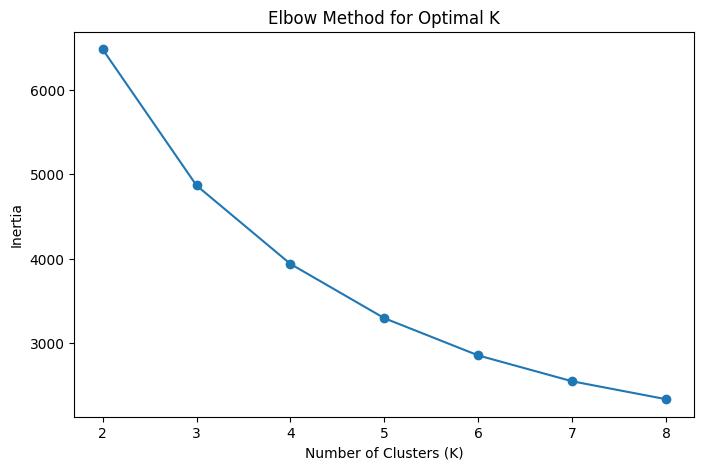

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 9))
plt.show()

In [12]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,0


In [13]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,134.14,1.67,497.74
1,25.88,8.44,4548.26


In [14]:
# Assign meaningful business segment names
segment_names = {
    0: "At Risk / Low Value",
    1: "High Value / Loyal"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,1,High Value / Loyal
12347.0,2,7,4310.00,1,High Value / Loyal
12348.0,75,4,1797.24,1,High Value / Loyal
12349.0,19,1,1757.55,0,At Risk / Low Value
12350.0,310,1,334.40,0,At Risk / Low Value


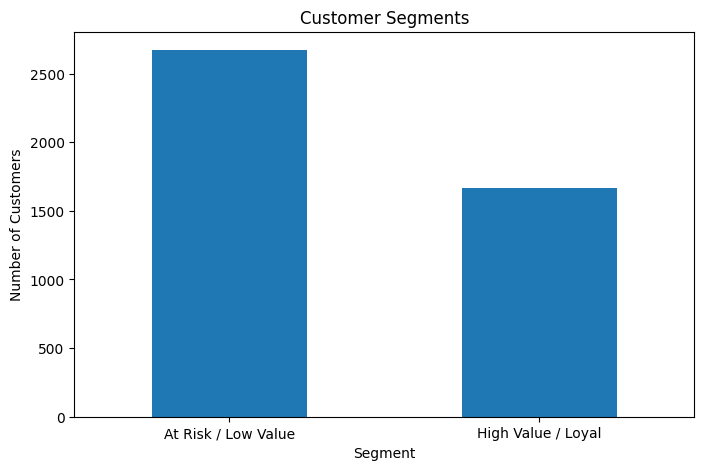

In [15]:
plt.figure(figsize=(8, 5))

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

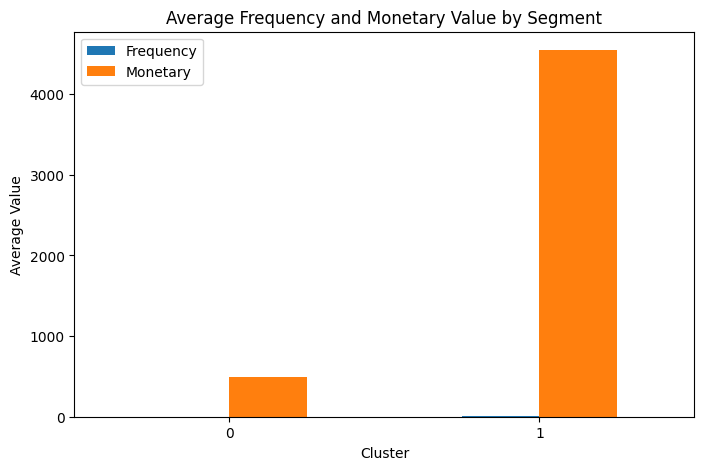

In [16]:
plt.figure(figsize=(8, 5))

cluster_summary[["Frequency", "Monetary"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Frequency and Monetary Value by Segment")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [17]:
segment_summary = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk / Low Value,134.14,1.67,497.74
High Value / Loyal,25.88,8.44,4548.26


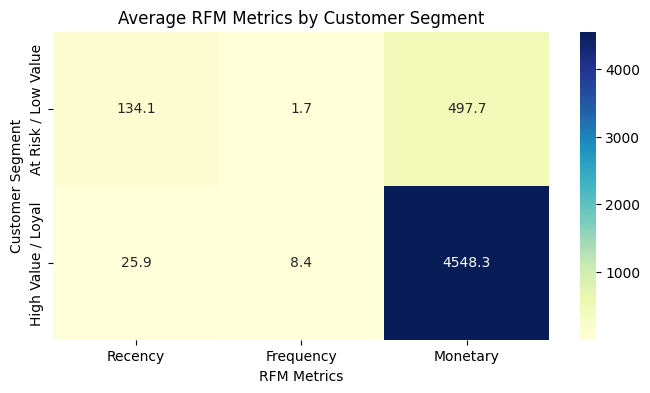

In [18]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    segment_summary,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average RFM Metrics by Customer Segment")
plt.xlabel("RFM Metrics")
plt.ylabel("Customer Segment")
plt.show()

In [19]:
segment_counts = rfm["Segment"].value_counts()

print("Customers in Each Segment:")
print(segment_counts)

Customers in Each Segment:
Segment
At Risk / Low Value    2671
High Value / Loyal     1667
Name: count, dtype: int64


In [20]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

print("Total Monetary Value by Segment:")
print(segment_revenue)

Total Monetary Value by Segment:
Segment
High Value / Loyal     7581946.781
At Risk / Low Value    1329461.123
Name: Monetary, dtype: float64


In [21]:
print("BUSINESS INSIGHTS")
print("-" * 50)

print("1. High Value / Loyal customers have lower recency,")
print("   higher purchase frequency, and higher spending.")

print("2. At Risk / Low Value customers have higher recency,")
print("   lower purchase frequency, and lower spending.")

print("3. High Value / Loyal customers should be retained")
print("   through loyalty rewards and personalized offers.")

print("4. At Risk / Low Value customers can be targeted")
print("   with re-engagement campaigns and special offers.")

BUSINESS INSIGHTS
--------------------------------------------------
1. High Value / Loyal customers have lower recency,
   higher purchase frequency, and higher spending.
2. At Risk / Low Value customers have higher recency,
   lower purchase frequency, and lower spending.
3. High Value / Loyal customers should be retained
   through loyalty rewards and personalized offers.
4. At Risk / Low Value customers can be targeted
   with re-engagement campaigns and special offers.


In [22]:
# Save final customer segmentation results
rfm.to_csv("customer_segments.csv")

# Save segment summary
segment_summary.to_csv("segment_summary.csv")

print("Output files saved successfully!")

Output files saved successfully!
